# EDA Course Project — Phase 1
### Dataset: S&P 500 Constituents (`constituents.csv`)

**Source:** https://raw.githubusercontent.com/salemprakash/EDA/main/Data/constituents.csv

**Tasks covered in this notebook (Phase 1 — 5 marks):**
1. Loading the dataset
2. Basic statistical analysis
3. Handling missing data
4. Data cleaning
5. Data transformation
6. Univariate analysis (≥ 3 visualizations)
7. Bivariate analysis (≥ 3 visualizations)
8. Multivariate analysis (≥ 3 visualizations)

> **Note on this dataset:** `constituents.csv` lists the companies that currently make up
> the S&P 500 index. It is mostly categorical (Symbol, Security name, GICS Sector,
> GICS Sub-Industry, Headquarters Location, Date added, CIK, Founded). To make
> statistical and visual analysis meaningful, we engineer a few numeric features
> from the raw text columns during the *Data Transformation* step (e.g. founding
> year, company age, years since added to the index).


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)


## 2. Loading the Dataset

The dataset is read directly from the raw GitHub URL supplied for the project.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/constituents.csv"

df = pd.read_csv(DATA_URL)

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (503, 8)


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


In [3]:
# Column names and data types
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Symbol                 503 non-null    str  
 1   Security               503 non-null    str  
 2   GICS Sector            503 non-null    str  
 3   GICS Sub-Industry      503 non-null    str  
 4   Headquarters Location  503 non-null    str  
 5   Date added             503 non-null    str  
 6   CIK                    503 non-null    int64
 7   Founded                503 non-null    str  
dtypes: int64(1), str(7)
memory usage: 31.6 KB


## 3. Basic Statistical Analysis

Since most columns are categorical (text), we look at:
- Summary statistics for numeric columns (e.g. `CIK`)
- Frequency-based summary statistics for categorical columns
- Cardinality (number of unique values) of each column

In [4]:
# Numeric summary (CIK is the only pure numeric column in the raw data)
df.describe(include=[np.number])


,CIK
count,5.030000e+02
mean,8.217536e+05
std,5.665200e+05
min,1.800000e+03
25%,1.005050e+05
50%,9.000750e+05
75%,1.175188e+06
max,2.005951e+06


In [5]:
# Categorical summary
df.describe(include=[object])


/tmp/ipykernel_511/3634800323.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=[object])


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,Founded
count,503,503,503,503,503,503,503
unique,503,503,11,127,252,376,199
top,MMM,3M,Industrials,Health Care Equipment,"New York City, New York",1957-03-04,1993
freq,1,1,78,18,41,54,13


In [6]:
# Number of unique values per column
df.nunique().sort_values(ascending=False)


Symbol                   503
Security                 503
CIK                      500
Date added               376
Headquarters Location    252
Founded                  199
GICS Sub-Industry        127
GICS Sector               11
dtype: int64

In [7]:
# How many companies per GICS Sector
df['GICS Sector'].value_counts()


GICS Sector
Industrials               78
Financials                71
Information Technology    67
Health Care               63
Consumer Discretionary    52
Consumer Staples          38
Utilities                 31
Real Estate               31
Materials                 28
Communication Services    22
Energy                    22
Name: count, dtype: int64

## 4. Handling Missing Data

We check every column for missing (`NaN`) values and decide how to treat them.

In [8]:
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().mean() * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing_counts, 'missing_%': missing_pct})
missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)


,missing_count,missing_%


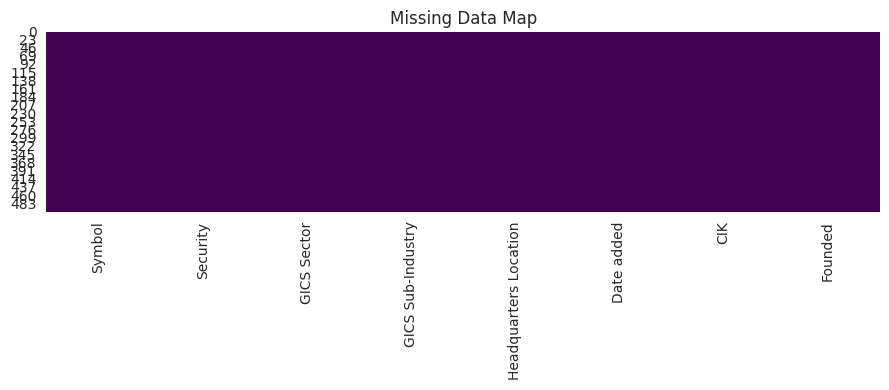

In [9]:
# Visual check for missing data
plt.figure(figsize=(9, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Map')
plt.tight_layout()
plt.show()


In [10]:
# Strategy:
# - 'Founded' occasionally has multiple/alternate years in parentheses e.g. "2020 (1915, spinoff)"
#   -> treated in Data Cleaning, not a missing-value issue.
# - Any row that is fully duplicated is dropped.
# - Any critical identifier (Symbol, Security) that is missing would be dropped,
#   since there is no way to impute a company's ticker/name.
critical_cols = ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry']
before = len(df)
df = df.dropna(subset=critical_cols)
after = len(df)
print(f"Rows before dropping missing critical fields: {before}")
print(f"Rows after dropping missing critical fields:  {after}")


Rows before dropping missing critical fields: 503
Rows after dropping missing critical fields:  503


## 5. Data Cleaning

Steps performed:
1. Remove exact duplicate rows.
2. Trim whitespace from text columns.
3. Standardise the `Date added` column to a proper `datetime` type.
4. Clean the messy `Founded` column (it sometimes contains text like
   `"2020 (1915, United Technologies spinoff)"`) down to a single usable year.


In [11]:
# 1. Remove duplicates
dup_count = df.duplicated().sum()
print("Exact duplicate rows found:", dup_count)
df = df.drop_duplicates().reset_index(drop=True)


Exact duplicate rows found: 0


In [12]:
# 2. Trim whitespace on all string/object columns
obj_cols = df.select_dtypes(include='object').columns
for c in obj_cols:
    df[c] = df[c].astype(str).str.strip()


/tmp/ipykernel_511/66306500.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = df.select_dtypes(include='object').columns


In [13]:
# 3. Convert 'Date added' to datetime
df['Date added'] = pd.to_datetime(df['Date added'], errors='coerce')
print("Rows where 'Date added' could not be parsed:", df['Date added'].isnull().sum())


Rows where 'Date added' could not be parsed: 0


In [14]:
# 4. Clean the 'Founded' column -> extract the first 4-digit year mentioned
def extract_founded_year(value):
    match = re.search(r'(\d{4})', str(value))
    return int(match.group(1)) if match else np.nan

df['Founded_Year_Clean'] = df['Founded'].apply(extract_founded_year)
df[['Founded', 'Founded_Year_Clean']].head(10)


,Founded,Founded_Year_Clean
0,1902,1902
1,1916,1916
2,1888,1888
3,2013 (1888),2013
4,1989,1989
5,1982,1982
6,1969,1969
7,1981,1981
8,1955,1955
9,1999,1999


In [15]:
# Sanity check: any implausible founding years (e.g. before 1600 or after this year)?
current_year = pd.Timestamp.today().year
implausible = df[(df['Founded_Year_Clean'] < 1600) | (df['Founded_Year_Clean'] > current_year)]
print("Implausible founding years:", len(implausible))
implausible[['Security', 'Founded', 'Founded_Year_Clean']]


Implausible founding years: 0


,Security,Founded,Founded_Year_Clean


In [16]:
# 5. Split 'Headquarters Location' into City and State/Country (best-effort)
loc_split = df['Headquarters Location'].str.rsplit(',', n=1, expand=True)
df['HQ_City'] = loc_split[0].str.strip()
df['HQ_State_Country'] = loc_split[1].str.strip()

df[['Headquarters Location', 'HQ_City', 'HQ_State_Country']].head()


,Headquarters Location,HQ_City,HQ_State_Country
0,"Saint Paul, Minnesota",Saint Paul,Minnesota
1,"Milwaukee, Wisconsin",Milwaukee,Wisconsin
2,"North Chicago, Illinois",North Chicago,Illinois
3,"North Chicago, Illinois",North Chicago,Illinois
4,"Dublin, Ireland",Dublin,Ireland


## 6. Data Transformation

We engineer numeric features from the cleaned data so that statistical and
visual analysis (histograms, correlations, etc.) becomes meaningful:

- **Date_Added_Year** — year the company joined the S&P 500
- **Company_Age** — years since the company was founded
- **Years_In_Index** — years since the company was added to the index


In [17]:
df['Date_Added_Year'] = df['Date added'].dt.year
df['Company_Age'] = current_year - df['Founded_Year_Clean']
df['Years_In_Index'] = current_year - df['Date_Added_Year']

# Bucket companies into founding-era categories for easier grouping later
bins = [0, 1900, 1950, 1980, 2000, 2010, current_year]
labels = ['Pre-1900', '1900-1950', '1951-1980', '1981-2000', '2001-2010', '2011-Present']
df['Founded_Era'] = pd.cut(df['Founded_Year_Clean'], bins=bins, labels=labels)

df[['Security', 'Founded_Year_Clean', 'Company_Age', 'Date_Added_Year', 'Years_In_Index', 'Founded_Era']].head()


,Security,Founded_Year_Clean,Company_Age,Date_Added_Year,Years_In_Index,Founded_Era
0,3M,1902,124,1957,69,1900-1950
1,A. O. Smith,1916,110,2017,9,1900-1950
2,Abbott Laboratories,1888,138,1957,69,Pre-1900
3,AbbVie,2013,13,2012,14,2011-Present
4,Accenture,1989,37,2011,15,1981-2000


In [18]:
# Final cleaned & transformed dataset overview
print("Final shape:", df.shape)
df.dtypes


Final shape: (503, 15)


Symbol                              str
Security                            str
GICS Sector                         str
GICS Sub-Industry                   str
Headquarters Location               str
Date added               datetime64[us]
CIK                               int64
Founded                             str
Founded_Year_Clean                int64
HQ_City                             str
HQ_State_Country                    str
Date_Added_Year                   int32
Company_Age                       int64
Years_In_Index                    int32
Founded_Era                    category
dtype: object

## 7. Univariate Analysis (≥ 3 visualizations)

Examining the distribution of single variables at a time.

/tmp/ipykernel_511/123482491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='GICS Sector', order=order, palette='viridis')


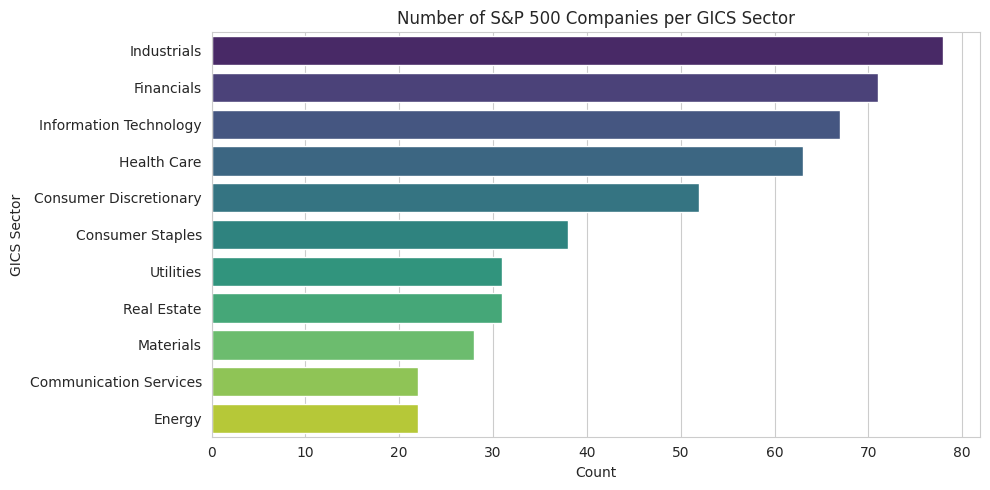

In [19]:
# (1) Number of companies per GICS Sector
plt.figure(figsize=(10, 5))
order = df['GICS Sector'].value_counts().index
sns.countplot(data=df, y='GICS Sector', order=order, palette='viridis')
plt.title('Number of S&P 500 Companies per GICS Sector')
plt.xlabel('Count')
plt.ylabel('GICS Sector')
plt.tight_layout()
plt.show()


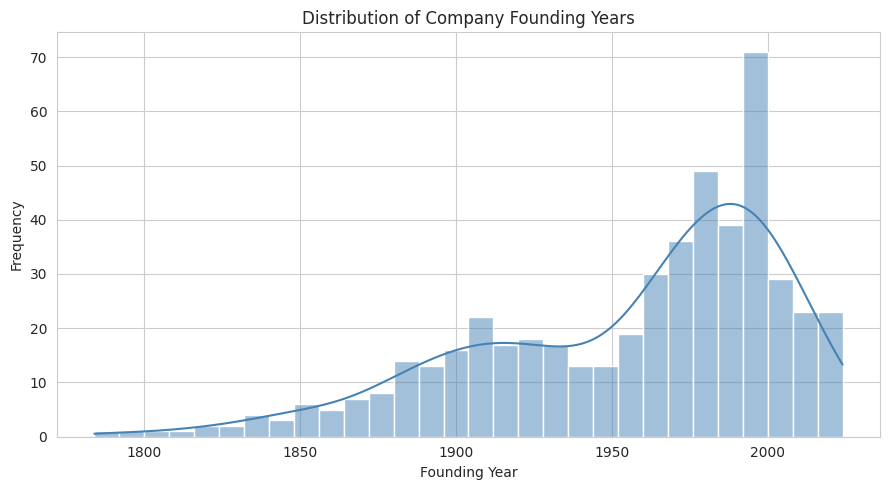

In [20]:
# (2) Distribution of company founding years
plt.figure()
sns.histplot(df['Founded_Year_Clean'].dropna(), bins=30, kde=True, color='steelblue')
plt.title('Distribution of Company Founding Years')
plt.xlabel('Founding Year')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


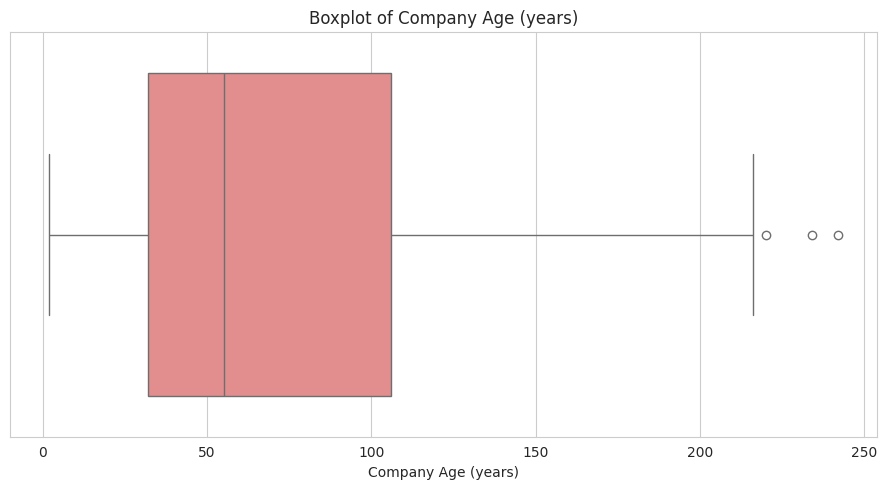

In [21]:
# (3) Distribution of company age (years since founding)
plt.figure()
sns.boxplot(x=df['Company_Age'], color='lightcoral')
plt.title('Boxplot of Company Age (years)')
plt.xlabel('Company Age (years)')
plt.tight_layout()
plt.show()


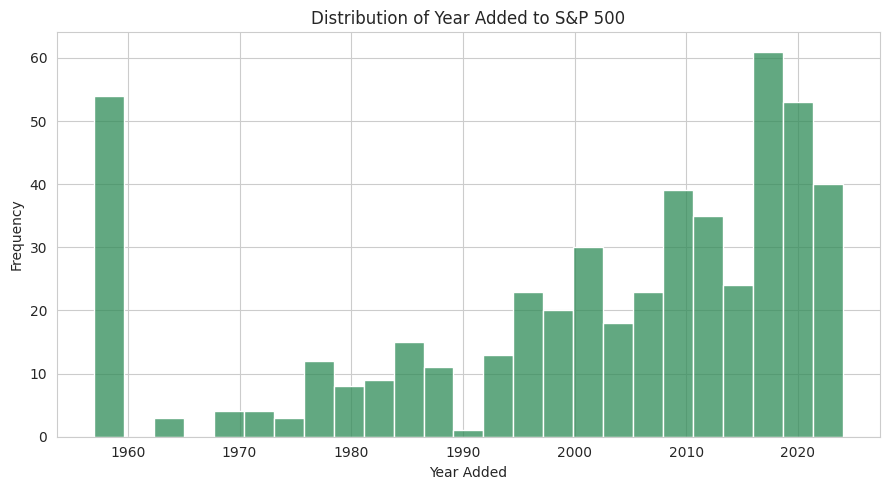

In [22]:
# (4) Distribution of the year companies were added to the S&P 500
plt.figure()
sns.histplot(df['Date_Added_Year'].dropna(), bins=25, color='seagreen')
plt.title('Distribution of Year Added to S&P 500')
plt.xlabel('Year Added')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


## 8. Bivariate Analysis (≥ 3 visualizations)

Examining the relationship between two variables at a time.

/tmp/ipykernel_511/767783735.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Company_Age', y='GICS Sector', order=order, palette='coolwarm')


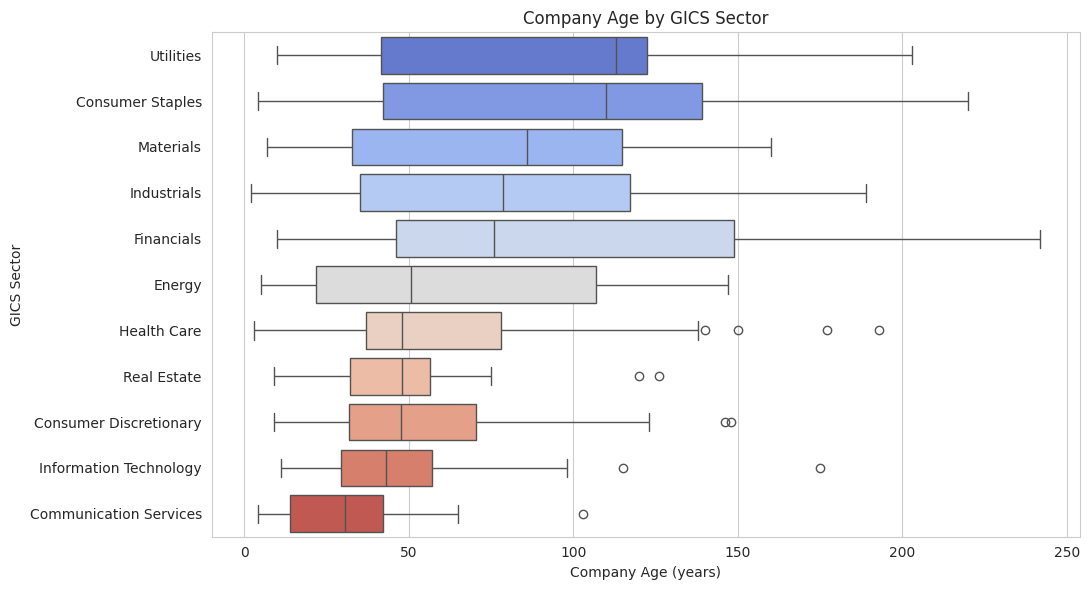

In [23]:
# (1) Company Age vs GICS Sector
plt.figure(figsize=(11, 6))
order = df.groupby('GICS Sector')['Company_Age'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Company_Age', y='GICS Sector', order=order, palette='coolwarm')
plt.title('Company Age by GICS Sector')
plt.xlabel('Company Age (years)')
plt.ylabel('GICS Sector')
plt.tight_layout()
plt.show()


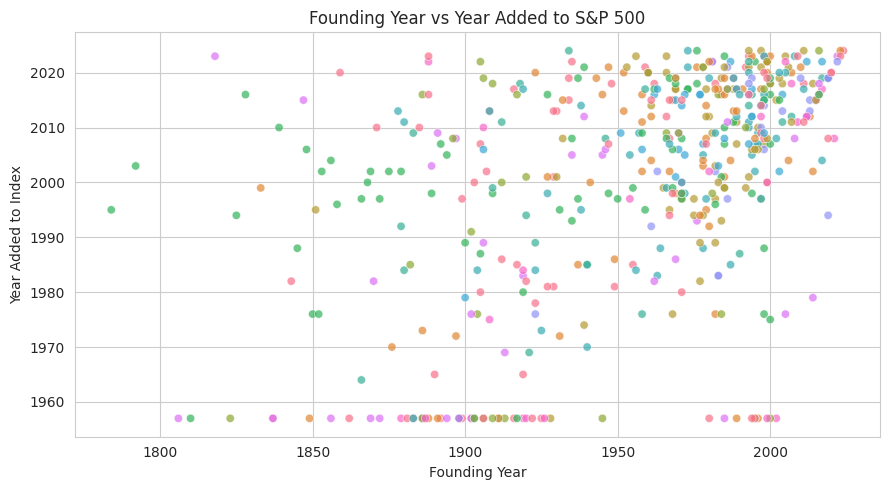

In [24]:
# (2) Founding Year vs Year Added to Index (scatter)
plt.figure()
sns.scatterplot(data=df, x='Founded_Year_Clean', y='Date_Added_Year',
                 hue='GICS Sector', legend=False, alpha=0.7)
plt.title('Founding Year vs Year Added to S&P 500')
plt.xlabel('Founding Year')
plt.ylabel('Year Added to Index')
plt.tight_layout()
plt.show()


/tmp/ipykernel_511/2335210733.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=era_counts.index, y=era_counts.values, palette='mako')


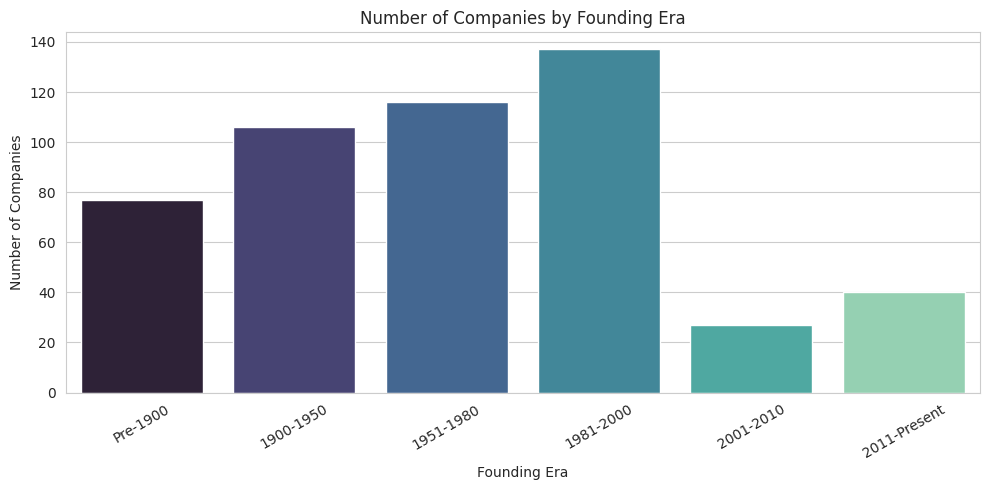

In [25]:
# (3) Number of companies added to the index per decade, by era of founding
plt.figure(figsize=(10, 5))
era_counts = df['Founded_Era'].value_counts().sort_index()
sns.barplot(x=era_counts.index, y=era_counts.values, palette='mako')
plt.title('Number of Companies by Founding Era')
plt.xlabel('Founding Era')
plt.ylabel('Number of Companies')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


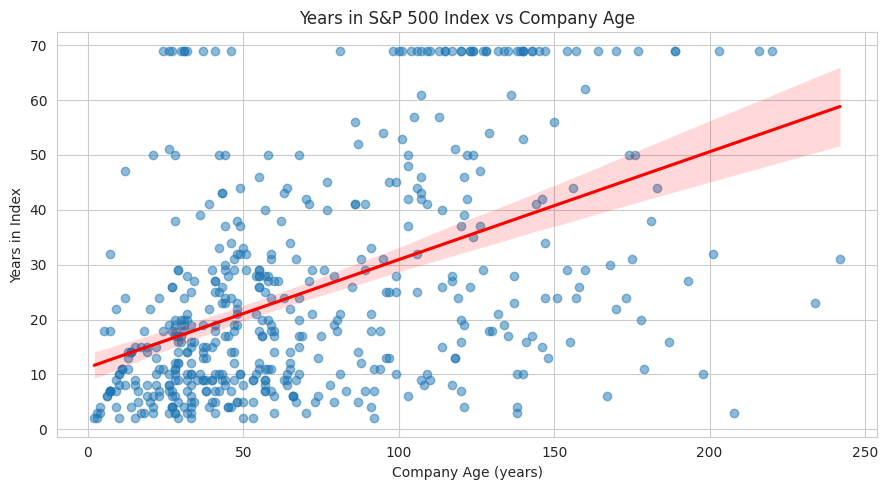

In [26]:
# (4) Years in Index vs Company Age
plt.figure()
sns.regplot(data=df, x='Company_Age', y='Years_In_Index',
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Years in S&P 500 Index vs Company Age')
plt.xlabel('Company Age (years)')
plt.ylabel('Years in Index')
plt.tight_layout()
plt.show()


## 9. Multivariate Analysis (≥ 3 visualizations)

Examining relationships across three or more variables together.

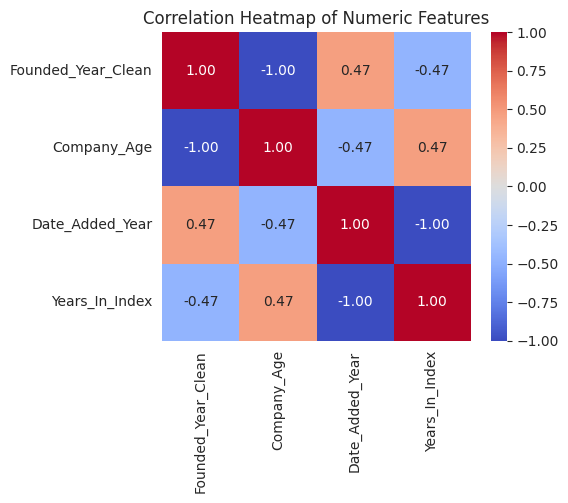

In [27]:
# (1) Correlation heatmap of engineered numeric features
numeric_cols = ['Founded_Year_Clean', 'Company_Age', 'Date_Added_Year', 'Years_In_Index']
corr = df[numeric_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


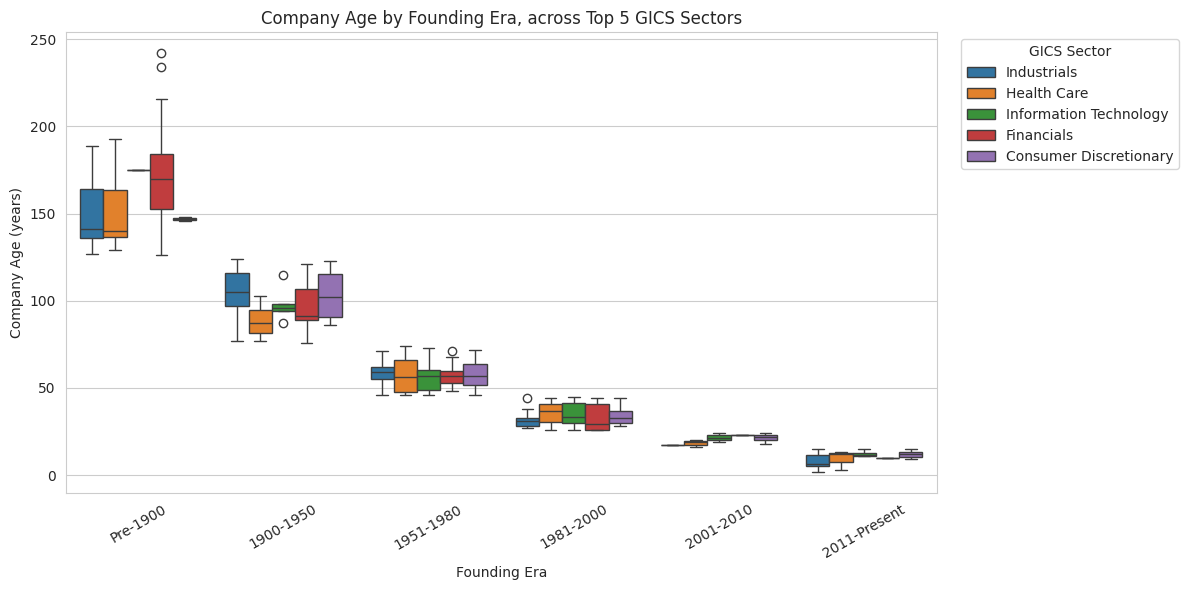

In [28]:
# (2) Company Age across Founding Era, split by top 5 GICS Sectors
top5_sectors = df['GICS Sector'].value_counts().head(5).index
subset = df[df['GICS Sector'].isin(top5_sectors)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x='Founded_Era', y='Company_Age', hue='GICS Sector')
plt.title('Company Age by Founding Era, across Top 5 GICS Sectors')
plt.xlabel('Founding Era')
plt.ylabel('Company Age (years)')
plt.xticks(rotation=30)
plt.legend(title='GICS Sector', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


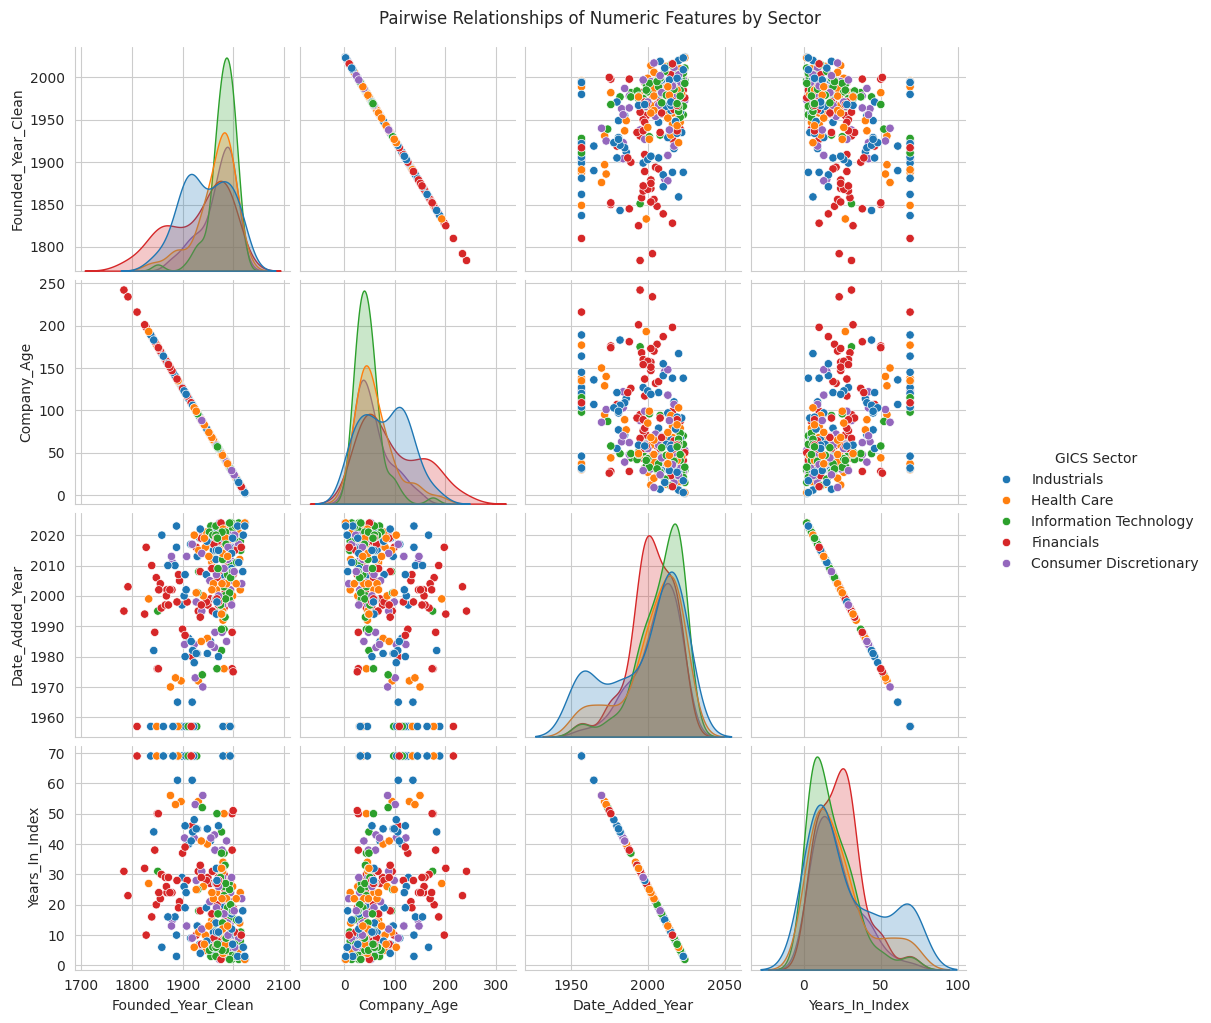

In [29]:
# (3) Pairplot of numeric features, coloured by top 5 GICS Sectors
sns.pairplot(subset[numeric_cols + ['GICS Sector']], hue='GICS Sector', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Numeric Features by Sector', y=1.02)
plt.show()


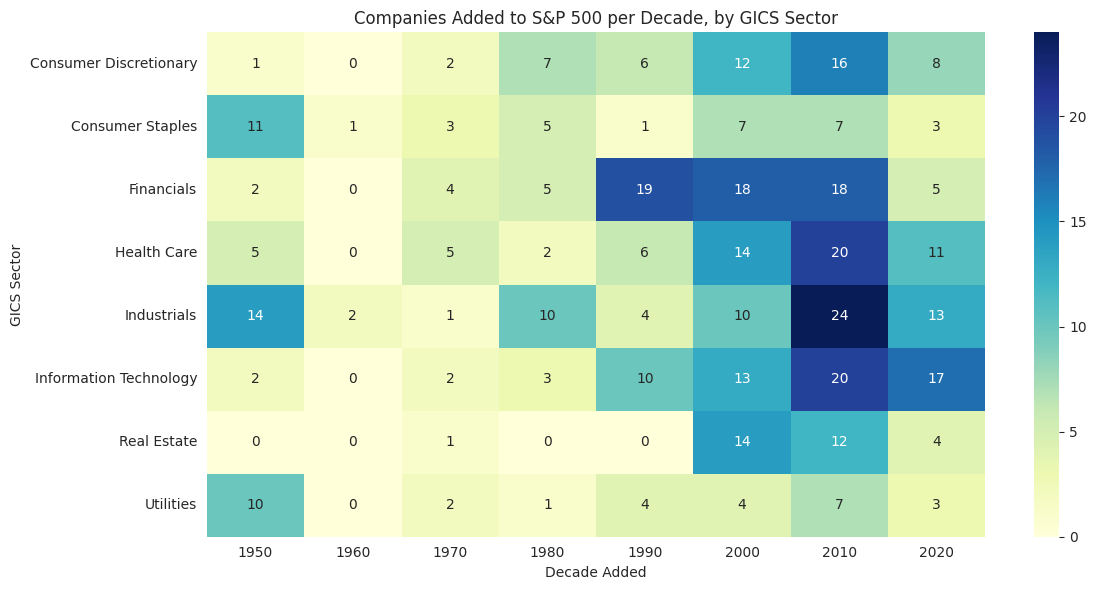

In [30]:
# (4) Heatmap: number of companies added per Year, by GICS Sector (top 8 sectors)
top8_sectors = df['GICS Sector'].value_counts().head(8).index
pivot = (df[df['GICS Sector'].isin(top8_sectors)]
         .assign(Decade=(df['Date_Added_Year'] // 10 * 10))
         .pivot_table(index='GICS Sector', columns='Decade', values='Symbol', aggfunc='count', fill_value=0))

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Companies Added to S&P 500 per Decade, by GICS Sector')
plt.xlabel('Decade Added')
plt.ylabel('GICS Sector')
plt.tight_layout()
plt.show()


## 10. Summary of Phase 1

- Dataset loaded directly from the shared GitHub URL.
- Explored structure, data types, and cardinality of every column.
- Checked and handled missing data (dropped rows missing critical identifiers).
- Cleaned duplicate rows, whitespace, dates, and the messy `Founded` text field.
- Engineered new numeric features (`Company_Age`, `Years_In_Index`, `Founded_Era`, HQ split) to enable analysis.
- Produced 4 univariate, 4 bivariate, and 4 multivariate visualizations (each ≥ the required minimum of 3).

**Next (Phase 2 / Phase 3):** deeper statistical testing, feature engineering for modeling, and predictive analysis will build on this cleaned dataset.
